# Round 3 Data Analysis

这个 notebook 用来先理解 Round 3 的自动交易数据。

目标不是马上写策略，而是先回答几个问题：

- 数据里有哪些商品？
- 每个商品价格大概在什么区间？
- 买卖盘价差有多大？
- 历史成交是否活跃？
- `VEV_xxxx` 这些 voucher 和 `VELVETFRUIT_EXTRACT` 有什么关系？

你可以从上往下逐格运行。

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DATA_DIR = Path("ROUND3_Data")
PRICE_FILES = sorted(DATA_DIR.glob("prices_round_3_day_*.csv"))
TRADE_FILES = sorted(DATA_DIR.glob("trades_round_3_day_*.csv"))

PRICE_FILES, TRADE_FILES

([PosixPath('ROUND3_Data/prices_round_3_day_0.csv'),
  PosixPath('ROUND3_Data/prices_round_3_day_1.csv'),
  PosixPath('ROUND3_Data/prices_round_3_day_2.csv')],
 [PosixPath('ROUND3_Data/trades_round_3_day_0.csv'),
  PosixPath('ROUND3_Data/trades_round_3_day_1.csv'),
  PosixPath('ROUND3_Data/trades_round_3_day_2.csv')])

## 1. 读取数据

这些 CSV 用分号 `;` 分隔，不是普通逗号。价格数据每个 day 有 10000 个 timestamp，每个 timestamp 对每个产品都有一行订单簿快照。

In [2]:
prices = pd.concat([pd.read_csv(path, sep=";") for path in PRICE_FILES], ignore_index=True)
trades = pd.concat([pd.read_csv(path, sep=";") for path in TRADE_FILES], ignore_index=True)

# 加一个跨 day 连续时间，画图更方便。
prices["global_time"] = prices["day"] * 1_000_000 + prices["timestamp"]

display(prices.head())
display(trades.head())
print("prices shape:", prices.shape)
print("trades shape:", trades.shape)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,global_time
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0,0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0,0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0,0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0,0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0,0


,timestamp,buyer,seller,symbol,currency,price,quantity
0,2500,NaN,NaN,VELVETFRUIT_EXTRACT,XIRECS,5250.0,4
1,2900,NaN,NaN,VEV_5400,XIRECS,22.0,3
2,2900,NaN,NaN,VEV_5500,XIRECS,8.0,3
3,2900,NaN,NaN,VEV_6000,XIRECS,0.0,3
4,2900,NaN,NaN,VEV_6500,XIRECS,0.0,3


prices shape: (360000, 18)
trades shape: (4048, 7)


## 2. 商品列表

`HYDROGEL_PACK` 和 `VELVETFRUIT_EXTRACT` 是普通现货。`VEV_4000` 到 `VEV_6500` 是基于 `VELVETFRUIT_EXTRACT` 的看涨期权 voucher。

In [3]:
products = sorted(prices["product"].unique())
products

['HYDROGEL_PACK',
 'VELVETFRUIT_EXTRACT',
 'VEV_4000',
 'VEV_4500',
 'VEV_5000',
 'VEV_5100',
 'VEV_5200',
 'VEV_5300',
 'VEV_5400',
 'VEV_5500',
 'VEV_6000',
 'VEV_6500']

In [4]:
summary = (
    prices.groupby("product")
    .agg(
        rows=("mid_price", "size"),
        mean_mid=("mid_price", "mean"),
        std_mid=("mid_price", "std"),
        min_mid=("mid_price", "min"),
        max_mid=("mid_price", "max"),
        mean_best_bid=("bid_price_1", "mean"),
        mean_best_ask=("ask_price_1", "mean"),
    )
    .sort_index()
)
summary["mean_spread"] = summary["mean_best_ask"] - summary["mean_best_bid"]
summary.round(3)

,rows,mean_mid,std_mid,min_mid,max_mid,mean_best_bid,mean_best_ask,mean_spread
product,,,,,,,,
HYDROGEL_PACK,30000,9990.807,31.935,9891.0,10079.0,9982.946,9998.667,15.721
VELVETFRUIT_EXTRACT,30000,5250.098,15.630,5198.0,5300.0,5247.604,5252.592,4.988
VEV_4000,30000,1250.110,15.647,1198.0,1300.0,1239.703,1260.517,20.813
VEV_4500,30000,750.110,15.640,698.5,799.5,742.183,758.036,15.853
VEV_5000,30000,255.022,14.376,206.5,300.5,252.001,258.044,6.043
VEV_5100,30000,166.805,12.743,125.0,205.5,164.658,168.953,4.296
VEV_5200,30000,95.549,9.664,64.0,122.5,94.105,96.993,2.888
VEV_5300,30000,46.760,6.228,26.5,65.5,45.707,47.813,2.107
VEV_5400,30000,15.952,3.429,6.5,27.0,15.261,16.643,1.381


## 3. 价格走势

先看两个现货。策略上它们可以先当成两个普通时间序列：找均值回归、趋势、价差和订单簿形态。

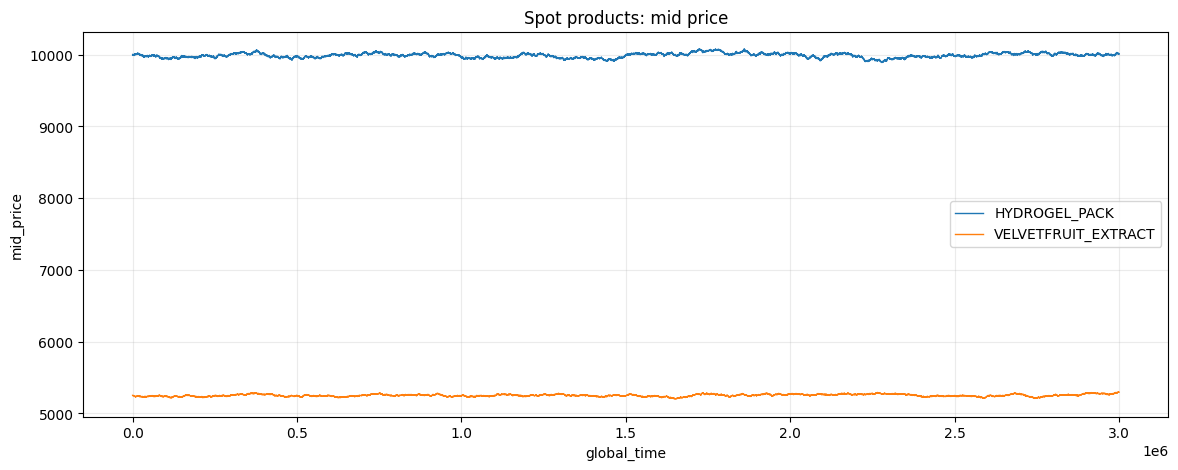

In [5]:
def plot_mid(products_to_plot, title=None, rolling=None):
    plt.figure(figsize=(14, 5))
    for product in products_to_plot:
        s = prices.loc[prices["product"] == product].sort_values(["day", "timestamp"])
        y = s["mid_price"]
        if rolling:
            y = y.rolling(rolling, min_periods=1).mean()
        plt.plot(s["global_time"], y, label=product, linewidth=1)
    plt.title(title or "Mid price")
    plt.xlabel("global_time")
    plt.ylabel("mid_price")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

plot_mid(["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"], "Spot products: mid price")

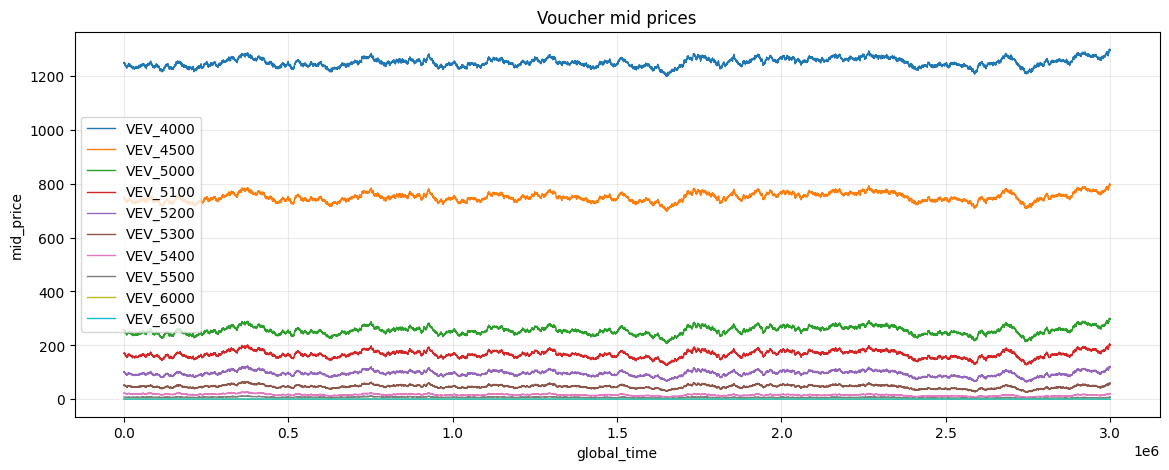

In [6]:
vouchers = [p for p in products if p.startswith("VEV_")]
plot_mid(vouchers, "Voucher mid prices")

## 4. 买卖价差和订单簿厚度

最简单的交易成本就是 best ask - best bid。价差越小，越适合频繁做市；价差越大，越需要更强的信号。

In [7]:
book = prices.copy()
book["spread"] = book["ask_price_1"] - book["bid_price_1"]
book["best_bid_value"] = book["bid_price_1"] * book["bid_volume_1"].abs()
book["best_ask_value"] = book["ask_price_1"] * book["ask_volume_1"].abs()

spread_summary = (
    book.groupby("product")
    .agg(
        mean_spread=("spread", "mean"),
        median_spread=("spread", "median"),
        max_spread=("spread", "max"),
        mean_bid_vol=("bid_volume_1", lambda x: x.abs().mean()),
        mean_ask_vol=("ask_volume_1", lambda x: x.abs().mean()),
    )
    .sort_index()
)
spread_summary.round(3)

,mean_spread,median_spread,max_spread,mean_bid_vol,mean_ask_vol
product,,,,,
HYDROGEL_PACK,15.721,16.0,17,12.404,12.395
VELVETFRUIT_EXTRACT,4.988,5.0,6,37.825,37.801
VEV_4000,20.813,21.0,22,10.922,10.920
VEV_4500,15.853,16.0,17,8.951,8.949
VEV_5000,6.043,6.0,7,15.326,15.484
VEV_5100,4.296,4.0,6,19.248,19.348
VEV_5200,2.888,3.0,4,22.563,22.509
VEV_5300,2.107,2.0,3,20.284,20.243
VEV_5400,1.381,1.0,2,21.763,21.719


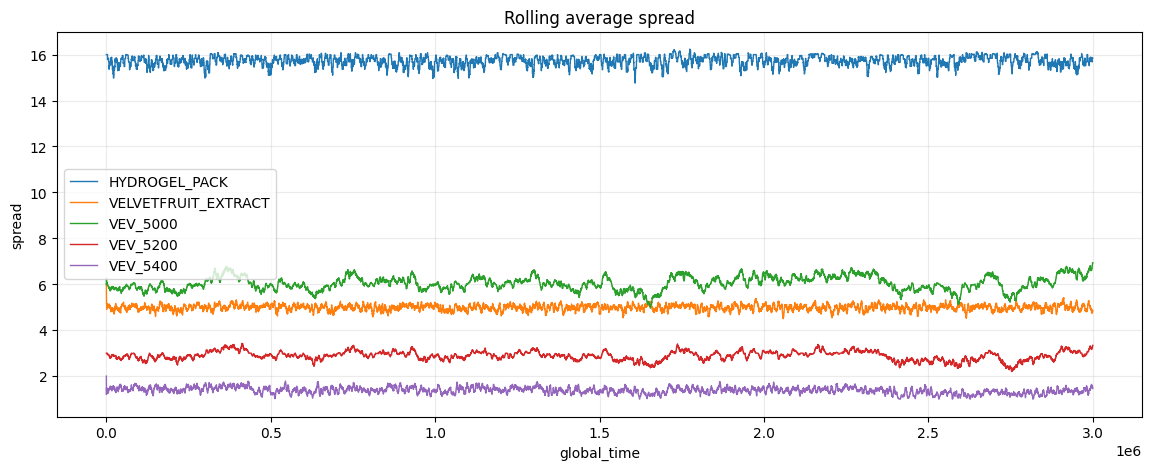

In [8]:
plt.figure(figsize=(14, 5))
for product in ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT", "VEV_5000", "VEV_5200", "VEV_5400"]:
    s = book.loc[book["product"] == product].sort_values(["day", "timestamp"])
    plt.plot(s["global_time"], s["spread"].rolling(50, min_periods=1).mean(), label=product, linewidth=1)
plt.title("Rolling average spread")
plt.xlabel("global_time")
plt.ylabel("spread")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 5. 历史成交数据

成交数据不是完整订单簿，只记录历史市场里实际发生的 trade。它能帮助我们判断哪些产品更活跃，以及成交价是否经常打到 bid/ask。

In [9]:
trade_summary = (
    trades.groupby("symbol")
    .agg(
        trades=("price", "size"),
        total_qty=("quantity", "sum"),
        avg_price=("price", "mean"),
        min_price=("price", "min"),
        max_price=("price", "max"),
    )
    .sort_index()
)
trade_summary.round(3)

,trades,total_qty,avg_price,min_price,max_price
symbol,,,,,
HYDROGEL_PACK,1010,4078,9990.486,9890.0,10086.0
VELVETFRUIT_EXTRACT,1372,8269,5250.477,5198.0,5291.0
VEV_4000,464,940,1249.815,1196.0,1307.0
VEV_4500,1,1,733.000,733.0,733.0
VEV_5000,1,1,238.000,238.0,238.0
VEV_5100,1,1,152.000,152.0,152.0
VEV_5200,18,63,85.278,74.0,98.0
VEV_5300,121,420,44.157,28.0,58.0
VEV_5400,225,787,14.884,7.0,22.0


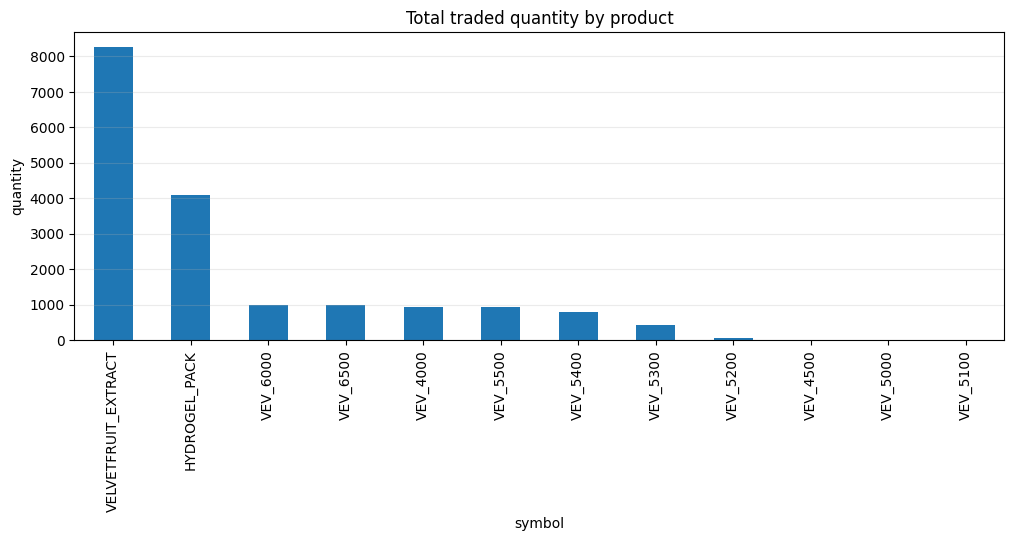

In [10]:
plt.figure(figsize=(12, 4))
trade_summary["total_qty"].sort_values(ascending=False).plot(kind="bar")
plt.title("Total traded quantity by product")
plt.ylabel("quantity")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 6. Voucher 的直觉价值

每个 `VEV_K` 是一个未来用 `K` 买入 `VELVETFRUIT_EXTRACT` 的权利。

如果当前现货价格是 `S`，一个非常粗糙的下界是：

`intrinsic_value = max(S - K, 0)`

真实 voucher 价格通常不只等于这个，因为还有未来波动带来的时间价值。下面先把 voucher 价格和这个粗糙下界比一比。

In [11]:
spot = (
    prices.loc[prices["product"] == "VELVETFRUIT_EXTRACT", ["day", "timestamp", "global_time", "mid_price"]]
    .rename(columns={"mid_price": "spot_mid"})
)

voucher_df = prices.loc[prices["product"].str.startswith("VEV_"), ["day", "timestamp", "global_time", "product", "mid_price"]].copy()
voucher_df["strike"] = voucher_df["product"].str.split("_").str[1].astype(int)
voucher_df = voucher_df.merge(spot, on=["day", "timestamp", "global_time"], how="left")
voucher_df["intrinsic"] = np.maximum(voucher_df["spot_mid"] - voucher_df["strike"], 0)
voucher_df["time_value"] = voucher_df["mid_price"] - voucher_df["intrinsic"]

voucher_summary = (
    voucher_df.groupby("product")
    .agg(
        strike=("strike", "first"),
        mean_voucher_mid=("mid_price", "mean"),
        mean_intrinsic=("intrinsic", "mean"),
        mean_time_value=("time_value", "mean"),
        min_time_value=("time_value", "min"),
        max_time_value=("time_value", "max"),
        corr_with_spot=("mid_price", lambda x: x.corr(voucher_df.loc[x.index, "spot_mid"])),
    )
    .sort_values("strike")
)
voucher_summary.round(3)

/Users/gujingxuan/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/gujingxuan/miniforge3/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,strike,mean_voucher_mid,mean_intrinsic,mean_time_value,min_time_value,max_time_value,corr_with_spot
product,,,,,,,
VEV_4000,4000,1250.110,1250.098,0.012,-7.0,7.0,0.999
VEV_4500,4500,750.110,750.098,0.011,-6.0,5.5,0.999
VEV_5000,5000,255.022,250.098,4.924,-0.5,11.5,0.995
VEV_5100,5100,166.805,150.098,16.707,4.5,29.5,0.962
VEV_5200,5200,95.549,50.098,45.450,21.5,67.5,0.914
VEV_5300,5300,46.760,0.000,46.760,26.5,65.5,0.837
VEV_5400,5400,15.952,0.000,15.952,6.5,27.0,0.573
VEV_5500,5500,6.641,0.000,6.641,2.5,12.5,0.493
VEV_6000,6000,0.500,0.000,0.500,0.5,0.5,NaN


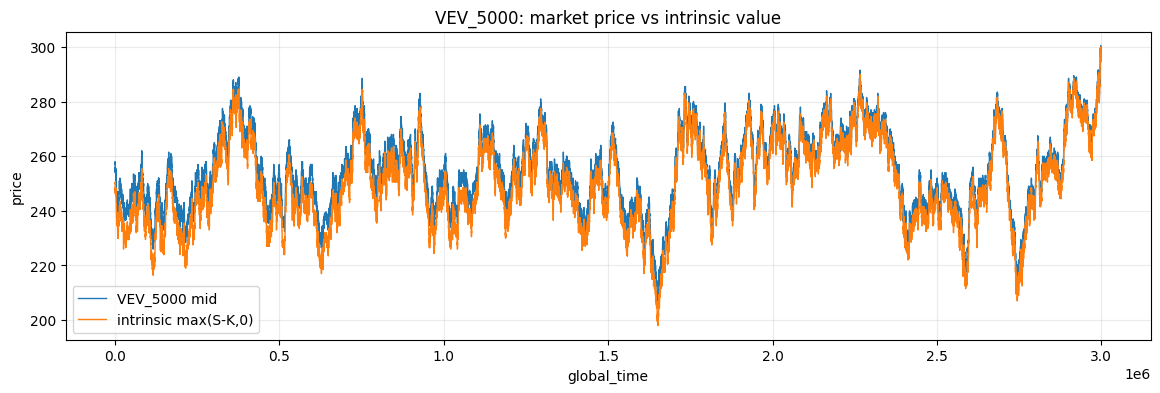

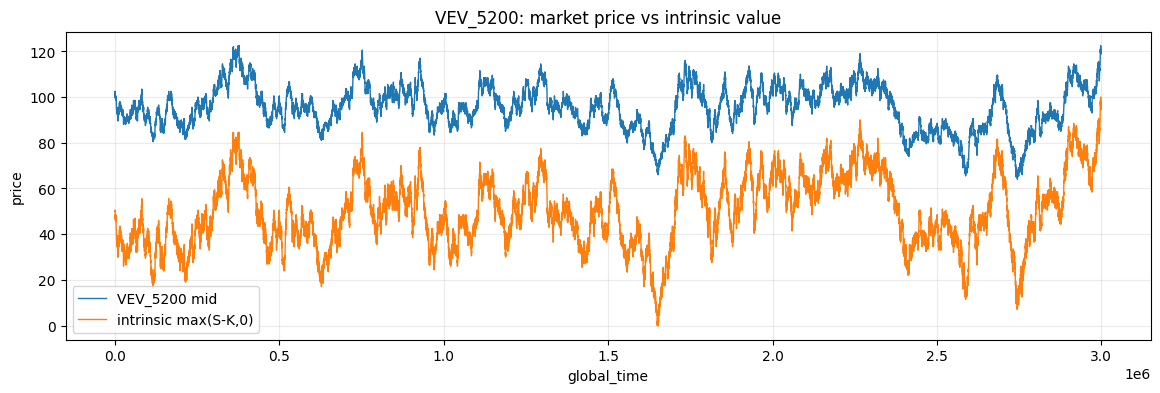

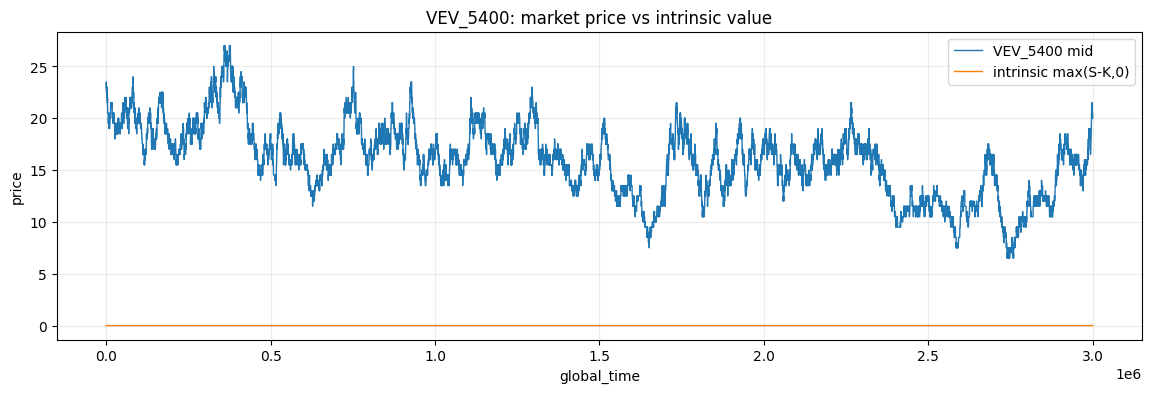

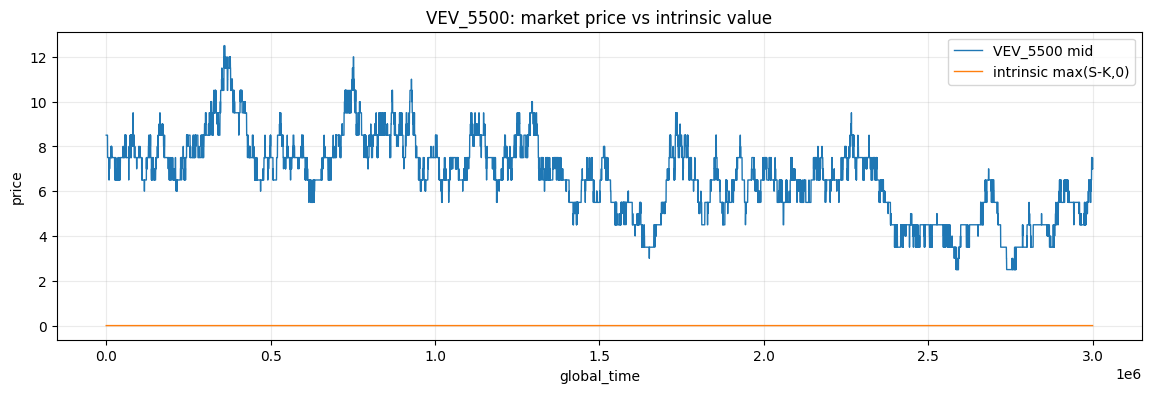

In [12]:
for product in ["VEV_5000", "VEV_5200", "VEV_5400", "VEV_5500"]:
    s = voucher_df.loc[voucher_df["product"] == product].sort_values(["day", "timestamp"])
    plt.figure(figsize=(14, 4))
    plt.plot(s["global_time"], s["mid_price"], label=f"{product} mid", linewidth=1)
    plt.plot(s["global_time"], s["intrinsic"], label="intrinsic max(S-K,0)", linewidth=1)
    plt.title(f"{product}: market price vs intrinsic value")
    plt.xlabel("global_time")
    plt.ylabel("price")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

## 7. 一个策略研究方向：用现货解释 voucher

从 CS 视角，可以先把 voucher 看成 `spot_mid`、`strike`、`TTE` 的函数。这里先做一个非常粗糙的线性检查：

- 如果某个 voucher 市场价明显低于模型估计值，考虑买入。
- 如果明显高于模型估计值，考虑卖出。

注意：这里不是最终策略，只是帮助我们看数据结构。

In [13]:
# 历史 day 0/1/2 对应 TTE 大约是 8/7/6 天，说明文件里有写。
voucher_df["tte_days"] = 8 - voucher_df["day"]
voucher_df["moneyness"] = voucher_df["spot_mid"] - voucher_df["strike"]

features = voucher_df[["spot_mid", "strike", "tte_days", "moneyness", "intrinsic", "mid_price"]].copy()
features.corr(numeric_only=True).round(3)

,spot_mid,strike,tte_days,moneyness,intrinsic,mid_price
spot_mid,1.000,0.000,-0.232,0.023,0.019,0.019
strike,0.000,1.000,-0.000,-1.000,-0.828,-0.841
tte_days,-0.232,-0.000,1.000,-0.005,-0.005,-0.001
moneyness,0.023,-1.000,-0.005,1.000,0.828,0.842
intrinsic,0.019,-0.828,-0.005,0.828,1.000,0.999
mid_price,0.019,-0.841,-0.001,0.842,0.999,1.000


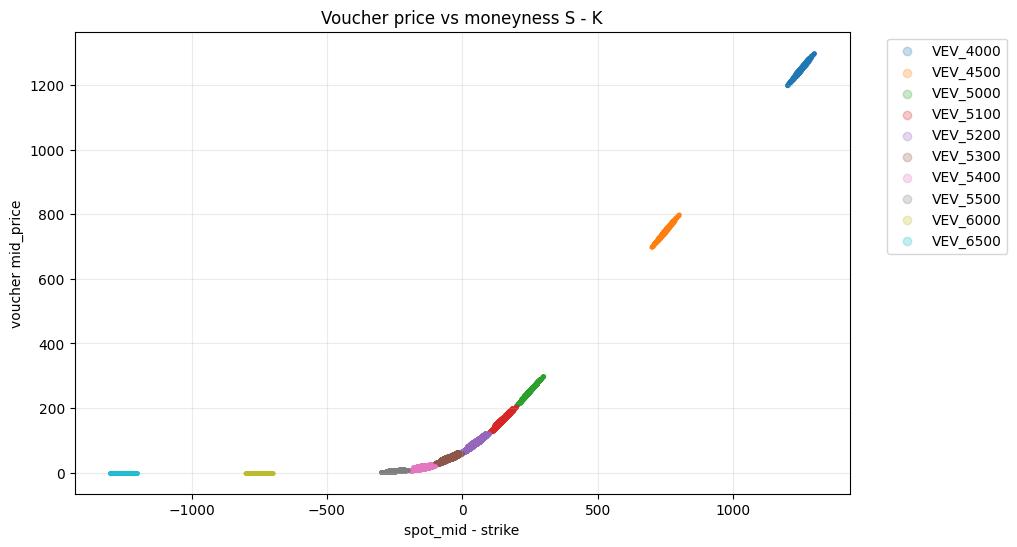

In [14]:
plt.figure(figsize=(10, 6))
for product in vouchers:
    s = voucher_df.loc[voucher_df["product"] == product]
    plt.scatter(s["moneyness"], s["mid_price"], s=4, alpha=0.25, label=product)
plt.title("Voucher price vs moneyness S - K")
plt.xlabel("spot_mid - strike")
plt.ylabel("voucher mid_price")
plt.grid(alpha=0.25)
plt.legend(markerscale=3, bbox_to_anchor=(1.04, 1), loc="upper left")
plt.show()

## 8. 先记下观察结论

运行完上面的图和表后，可以在这里写结论。建议关注：

- 哪些产品 spread 小，适合做市？
- 哪些产品 trade 多，说明市场更活跃？
- voucher 的 `time_value` 是否稳定？
- `VEV_6000` / `VEV_6500` 价格长期接近 0.5，是否有特殊交易机会或只是很难成交？
- `VELVETFRUIT_EXTRACT` 的波动是否足够解释 voucher 价格？

下一步可以基于这些观察写一个 baseline 策略：现货用简单均值回归/做市，voucher 用理论价偏差交易。